# 02 - Data Preprocessing & tf.data Pipelines

Building the `tf.data` pipeline for the vegetable dataset:

1. Load train / validation / test from `data/` with `image_dataset_from_directory`.
2. Resize to a fixed square size (**150 × 150**, the input size of the shipped model).
3. **No pixel normalization** — the model in `models/vegetable_cnn.h5` was trained on raw `[0, 255]` values.
4. Augment **train only** with geometric transforms (flip / rotate / zoom) that preserve the pixel range.
5. Verify by rendering augmented train images against plain validation images.

Figures are saved to `reports/figures/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from src.config import DATA_DIR, FIGURES_DIR, IMG_SIZE, BATCH_SIZE, SEED  # noqa: E402

print(f"TensorFlow {tf.__version__}")
AUTOTUNE = tf.data.AUTOTUNE
%matplotlib inline


I0000 00:00:1790237087.916390 1662751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790237088.074584 1662751 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790237095.350226 1662751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0


In [2]:

for split in ("train", "validation", "test"):
    if not (DATA_DIR / split).is_dir():
        raise SystemExit(f"Missing data/{split}. Run `python -m src.download_data` first.")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "validation",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print(f"{len(class_names)} classes (ordered alphabetically):")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")
assert val_ds.class_names == class_names and test_ds.class_names == class_names
print("\nClass ordering is identical across all splits.")


Found 15000 files belonging to 15 classes.


Found 3000 files belonging to 15 classes.


E0000 00:00:1790237101.283471 1662751 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 3000 files belonging to 15 classes.


15 classes (ordered alphabetically):
   0: Bean
   1: Bitter_Gourd
   2: Bottle_Gourd
   3: Brinjal
   4: Broccoli
   5: Cabbage
   6: Capsicum
   7: Carrot
   8: Cauliflower
   9: Cucumber
  10: Papaya
  11: Potato
  12: Pumpkin
  13: Radish
  14: Tomato

Class ordering is identical across all splits.


## A note on pixel range

The shipped model was trained on **raw pixel values in `[0, 255]`** (its BatchNorm layers learn the scale internally). So unlike many tutorials, we do **not** divide by 255. Feeding normalized `[0, 1]` values to this model collapses every prediction to one class.

In [3]:

# Geometric augmentation, applied ONLY to the training set.
# Range-preserving (flip / rotate / zoom), keeping values compatible with the
# raw-pixel model. No brightness shifts that could push pixels out of [0, 255].
augmenter = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED, name="rand_flip"),
        tf.keras.layers.RandomRotation(0.15, fill_mode="nearest", seed=SEED, name="rand_rot"),
        tf.keras.layers.RandomZoom(0.1, fill_mode="nearest", seed=SEED, name="rand_zoom"),
    ],
    name="augment",
)

def prep_augmented(x, y):
    return augmenter(x, training=True), y

def prep_plain(x, y):
    return x, y

train_ds = train_ds.map(prep_augmented, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(prep_plain, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(prep_plain, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

for name, ds in (("train", train_ds), ("validation", val_ds), ("test", test_ds)):
    print(f"{name:10s}: {len(ds):4d} batches x {BATCH_SIZE} = {len(ds) * BATCH_SIZE:,} images")


train     :  469 batches x 32 = 15,008 images
validation:   94 batches x 32 = 3,008 images
test      :   94 batches x 32 = 3,008 images


## 1) Verify: augmentations on a single image

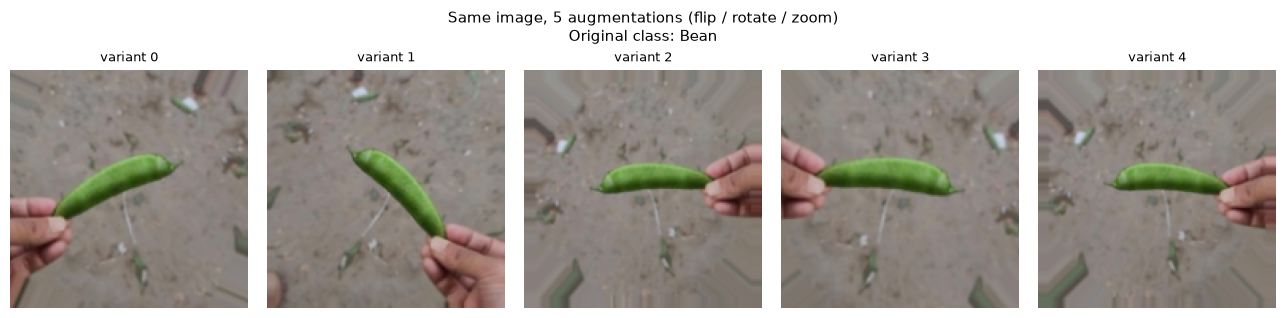

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/02_augmentation_samples.png


In [4]:

from PIL import Image as PILImage

single_path = next(
    p for p in (DATA_DIR / "train" / class_names[0]).iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
x = tf.convert_to_tensor(
    np.asarray(PILImage.open(single_path).convert("RGB").resize(IMG_SIZE))[None, ...]
)

variant_np = np.concatenate(
    [augmenter(x, training=True).numpy() for _ in range(5)], axis=0
)

fig, axes = plt.subplots(1, 5, figsize=(13, 3.2))
for j, ax in enumerate(axes):
    ax.imshow(np.clip(variant_np[j], 0.0, 255.0).astype(np.uint8))
    ax.set_title(f"variant {j}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Same image, 5 augmentations (flip / rotate / zoom)\nOriginal class: {class_names[0]}", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_augmentation_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"saved -> {FIGURES_DIR / '02_augmentation_samples.png'}")


## 2) Verify: a full batch of train (augmented) vs validation (plain)

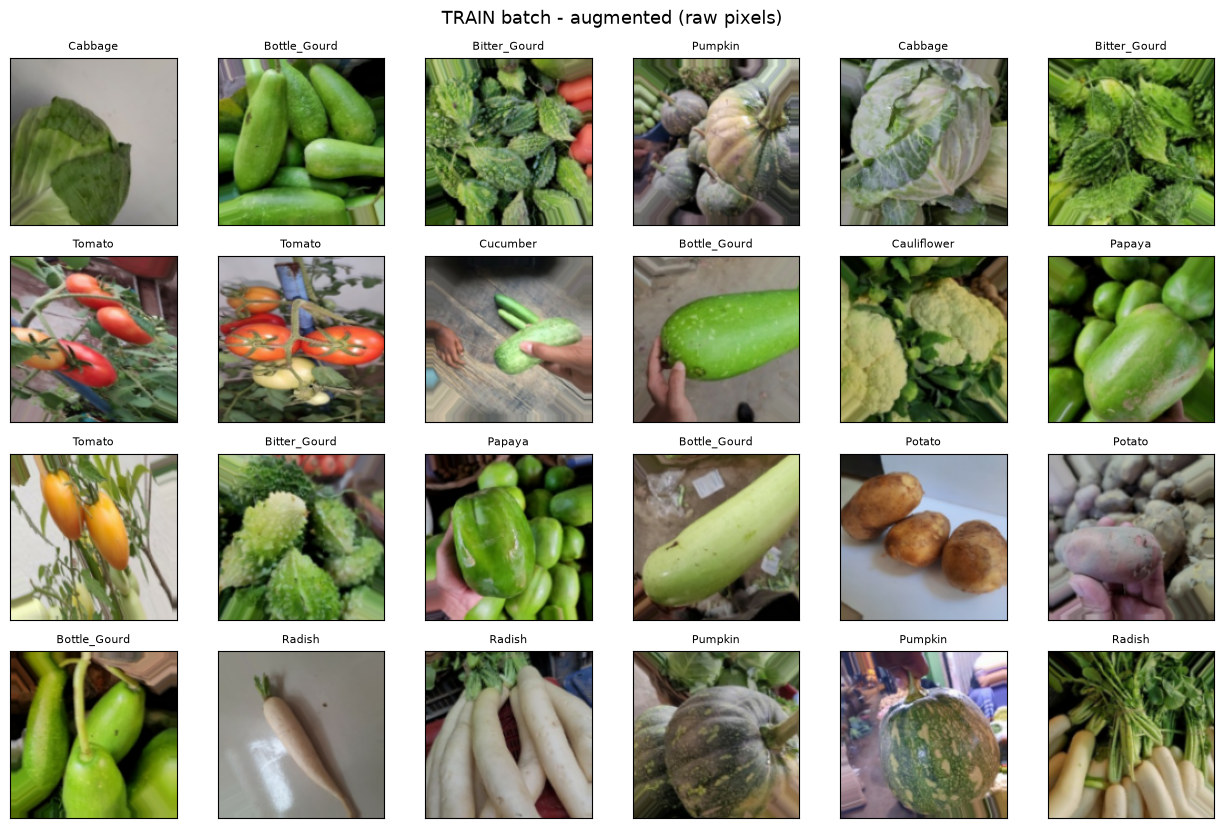

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/02_data_batches_train.png


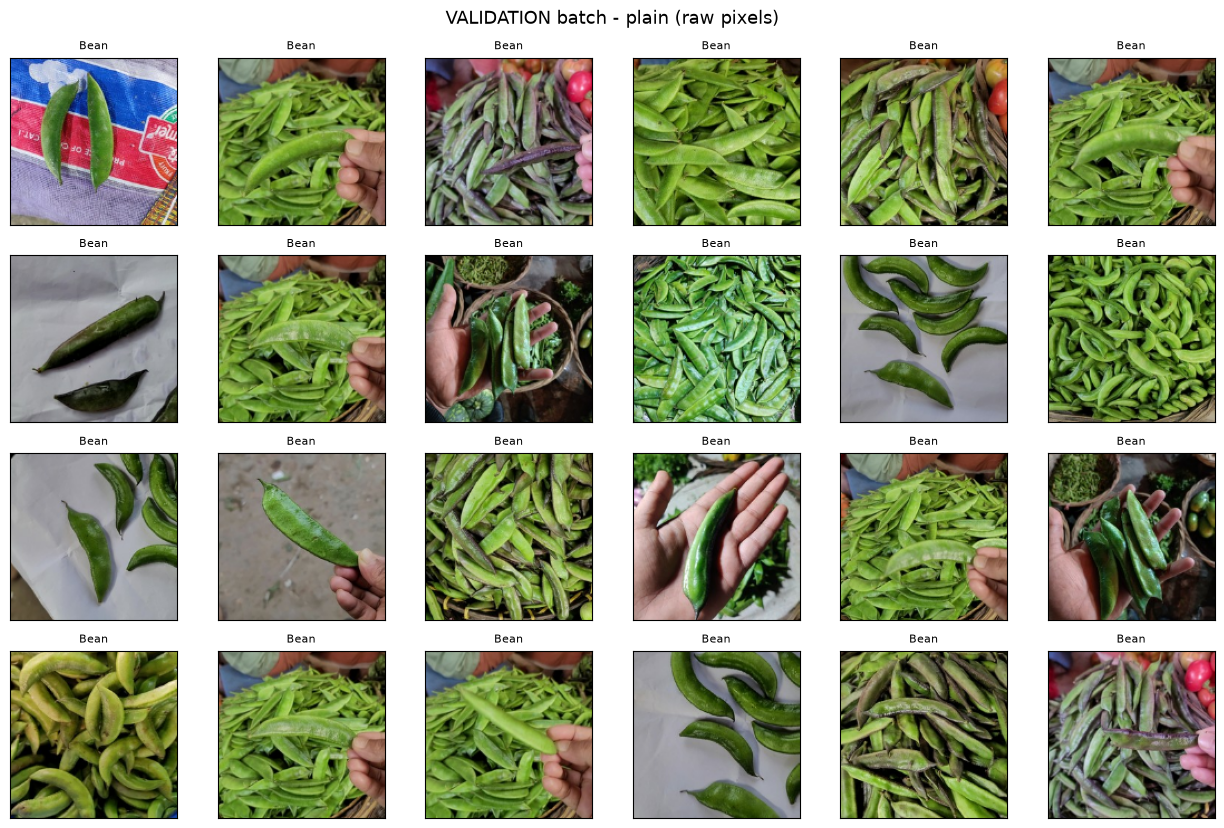

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/02_data_batches_validation.png


In [5]:

def show_batch(ds, title, out, max_items=24):
    images, labels = next(iter(ds.take(1)))
    n = min(max_items, len(images))
    cols, rows = 6, int(np.ceil(n / 6))
    fig, axes = plt.subplots(rows, cols, figsize=(2.1 * cols, 2.1 * rows))
    for i in range(n):
        ax = axes.flat[i]
        ax.imshow(np.clip(images[i].numpy(), 0.0, 255.0).astype(np.uint8))
        ax.set_title(class_names[int(np.argmax(labels[i].numpy()))], fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    for i in range(n, cols * rows):
        axes.flat[i].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"saved -> {out}")

show_batch(train_ds, "TRAIN batch - augmented (raw pixels)",
           FIGURES_DIR / "02_data_batches_train.png")
show_batch(val_ds, "VALIDATION batch - plain (raw pixels)",
           FIGURES_DIR / "02_data_batches_validation.png")


## Notes
- The train-batch cell shows a **different** image every run because augmentation is stochastic and re-applied each epoch — the model effectively sees a new variation of every image per epoch (regularization).
- Validation / test are deterministic (resize only), so metrics stay comparable.
- Pipelines are batched and prefetched, ready for `model.fit(...)` in `03_model_architecture.ipynb` / `04_train_on_kaggle.ipynb`.